# Setup

In [1]:
from pathlib import Path
import hashlib

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedGroupKFold
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

SEED = 42
N_SPLITS = 5
np.random.seed(SEED)

# Load Metadata

In [2]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

AUDIT_DIR = PROJECT_ROOT / "data" / "processed" / "audit"
CLEAN_DIR = PROJECT_ROOT / "data" / "processed" / "clean"
SPLIT_DIR = PROJECT_ROOT / "data" / "splits"
CLEAN_DIR.mkdir(parents=True, exist_ok=True)
SPLIT_DIR.mkdir(parents=True, exist_ok=True)

train_meta_path = AUDIT_DIR / "train_metadata.csv"
test_meta_path = AUDIT_DIR / "test_metadata.csv"

if not train_meta_path.exists() or not test_meta_path.exists():
    raise FileNotFoundError(
        "train_metadata.csv/test_metadata.csv belum ada. Jalankan notebook 01_eda_data_audit.ipynb dulu."
    )

train_df = pd.read_csv(train_meta_path)
test_df = pd.read_csv(test_meta_path)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"Train rows: {len(train_df)}")
print(f"Test rows: {len(test_df)}")
display(train_df.head())

PROJECT_ROOT: c:\Users\Axioo\Documents\Fahmi\ai\ml\findit-2026
Train rows: 1652
Test rows: 404


,split,label,file_name,file_path,ext,file_size
0,train,fake_mannequin,mannequin_001.jpg,c:\Users\Axioo\Documents\Fahmi\ai\ml\findit-20...,.jpg,32708
1,train,fake_mannequin,mannequin_002.jpg,c:\Users\Axioo\Documents\Fahmi\ai\ml\findit-20...,.jpg,215315
2,train,fake_mannequin,mannequin_003.jpg,c:\Users\Axioo\Documents\Fahmi\ai\ml\findit-20...,.jpg,125622
3,train,fake_mannequin,mannequin_004.jpg,c:\Users\Axioo\Documents\Fahmi\ai\ml\findit-20...,.jpg,149177
4,train,fake_mannequin,mannequin_005.jpg,c:\Users\Axioo\Documents\Fahmi\ai\ml\findit-20...,.jpg,116652


# Recompute Hash

In [3]:
def file_md5(path: str, chunk_size: int = 1024 * 1024) -> str:
    h = hashlib.md5()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()

train_df = train_df.copy()
test_df = test_df.copy()

train_df["md5"] = train_df["file_path"].apply(file_md5)
test_df["md5"] = test_df["file_path"].apply(file_md5)

print("Train unique hashes:", train_df["md5"].nunique())
print("Test unique hashes:", test_df["md5"].nunique())

Train unique hashes: 1474
Test unique hashes: 397


# Label Consistency Check

In [4]:
label_per_hash = train_df.groupby("md5")["label"].nunique().rename("n_unique_label")
ambiguous_hashes = label_per_hash[label_per_hash > 1].index

ambiguous_df = train_df[train_df["md5"].isin(ambiguous_hashes)].copy()
train_consistent_df = train_df[~train_df["md5"].isin(ambiguous_hashes)].copy()

train_dedup_df = (
    train_consistent_df
    .sort_values(["md5", "file_name"])
    .drop_duplicates(subset=["md5"], keep="first")
    .reset_index(drop=True)
)

print("Ambiguous hashes:", len(ambiguous_hashes))
print("Rows dropped (ambiguous):", len(ambiguous_df))
print("Rows after removing ambiguous:", len(train_consistent_df))
print("Rows after exact dedup by hash:", len(train_dedup_df))

display(train_dedup_df["label"].value_counts().rename("count").to_frame())
display(ambiguous_df.head())

Ambiguous hashes: 132
Rows dropped (ambiguous): 279
Rows after removing ambiguous: 1373
Rows after exact dedup by hash: 1342


,count
label,
realperson,385
fake_unknown,272
fake_mask,242
fake_screen,188
fake_mannequin,180
fake_printed,75


,split,label,file_name,file_path,ext,file_size,md5
4,train,fake_mannequin,mannequin_005.jpg,c:\Users\Axioo\Documents\Fahmi\ai\ml\findit-20...,.jpg,116652,3cda8be1b0f73cc0bdfb26590461cdf5
7,train,fake_mannequin,mannequin_008.jpg,c:\Users\Axioo\Documents\Fahmi\ai\ml\findit-20...,.jpg,28779,1138e937d40b575d67a0660f39655a7d
16,train,fake_mannequin,mannequin_017.jpg,c:\Users\Axioo\Documents\Fahmi\ai\ml\findit-20...,.jpg,119374,195f9010710c5d3c244a3a0286b4f074
23,train,fake_mannequin,mannequin_024.jpg,c:\Users\Axioo\Documents\Fahmi\ai\ml\findit-20...,.jpg,72854,cadf5f281346421bbd1a98fc9c72dc81
34,train,fake_mannequin,mannequin_035.jpg,c:\Users\Axioo\Documents\Fahmi\ai\ml\findit-20...,.jpg,30360,e6af5f5cfaa07952c014d83c975c376e


# Train Test Overlap Check

In [5]:
train_hashes = set(train_dedup_df["md5"])
test_hashes = set(test_df["md5"])

overlap_hashes = train_hashes.intersection(test_hashes)

overlap_df = train_dedup_df[train_dedup_df["md5"].isin(overlap_hashes)].copy()
print("Train-Test overlap hashes:", len(overlap_hashes))
display(overlap_df.head())

Train-Test overlap hashes: 73


,split,label,file_name,file_path,ext,file_size,md5
6,train,fake_mannequin,mannequin_154.jpg,c:\Users\Axioo\Documents\Fahmi\ai\ml\findit-20...,.jpg,104680,00df868421c798af231288f879d52e46
10,train,fake_mannequin,mannequin_155.jpg,c:\Users\Axioo\Documents\Fahmi\ai\ml\findit-20...,.jpg,43952,019fe6c12646777b29fc9220a1d757be
12,train,fake_mannequin,mannequin_182.jpg,c:\Users\Axioo\Documents\Fahmi\ai\ml\findit-20...,.jpg,1053846,0212731c7eb3da27868cfe456b4da15c
32,train,fake_mask,mask_123.jpg,c:\Users\Axioo\Documents\Fahmi\ai\ml\findit-20...,.jpg,4643630,045a8e4fd52b58c4b8333ea49c079b80
54,train,realperson,real_201.jpg,c:\Users\Axioo\Documents\Fahmi\ai\ml\findit-20...,.jpg,128168,08cbb30e130c4963e946b91d886b1e58


# Fold Split

In [6]:
sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

split_df = train_dedup_df.copy()
split_df["fold"] = -1

X = split_df[["file_path"]]
y = split_df["label"]
groups = split_df["md5"]

for fold, (_, val_idx) in enumerate(sgkf.split(X, y, groups=groups)):
    split_df.loc[val_idx, "fold"] = fold

assert (split_df["fold"] >= 0).all(), "Ada row yang belum mendapat fold"

leak_count = 0
for h, g in split_df.groupby("md5"):
    if g["fold"].nunique() > 1:
        leak_count += 1

print("Hash leakage across folds:", leak_count)
display(split_df["fold"].value_counts().sort_index().rename("count").to_frame())

Hash leakage across folds: 0


,count
fold,
0,269
1,269
2,268
3,268
4,268


# Save Outputs

In [7]:
train_df.to_csv(CLEAN_DIR / "train_metadata_with_hash.csv", index=False)
test_df.to_csv(CLEAN_DIR / "test_metadata_with_hash.csv", index=False)
ambiguous_df.to_csv(CLEAN_DIR / "train_ambiguous_hash_rows.csv", index=False)
train_dedup_df.to_csv(CLEAN_DIR / "train_dedup_clean.csv", index=False)
overlap_df.to_csv(CLEAN_DIR / "train_test_overlap_hash_rows.csv", index=False)

split_cols = ["label", "file_name", "file_path", "ext", "file_size", "md5", "fold"]
split_df[split_cols].to_csv(SPLIT_DIR / "train_5fold_stratified_group_seed42.csv", index=False)

summary = pd.DataFrame(
    {
        "metric": [
            "train_original_rows",
            "train_unique_hash",
            "ambiguous_hash_count",
            "ambiguous_rows",
            "train_dedup_rows",
            "test_rows",
            "train_test_overlap_hash",
        ],
        "value": [
            len(train_df),
            train_df["md5"].nunique(),
            len(ambiguous_hashes),
            len(ambiguous_df),
            len(train_dedup_df),
            len(test_df),
            len(overlap_hashes),
        ],
    }
)
summary.to_csv(SPLIT_DIR / "split_prep_summary.csv", index=False)

print(f"Saved clean metadata to: {CLEAN_DIR}")
print(f"Saved split file to: {SPLIT_DIR}")
display(summary)

Saved clean metadata to: c:\Users\Axioo\Documents\Fahmi\ai\ml\findit-2026\data\processed\clean
Saved split file to: c:\Users\Axioo\Documents\Fahmi\ai\ml\findit-2026\data\splits


,metric,value
0,train_original_rows,1652
1,train_unique_hash,1474
2,ambiguous_hash_count,132
3,ambiguous_rows,279
4,train_dedup_rows,1342
5,test_rows,404
6,train_test_overlap_hash,73


# Quick Validation

label,fake_mannequin,fake_mask,fake_printed,fake_screen,fake_unknown,realperson
fold,,,,,,
0,36,48,15,38,55,77
1,36,49,15,38,54,77
2,36,48,15,37,55,77
3,36,49,15,37,54,77
4,36,48,15,38,54,77


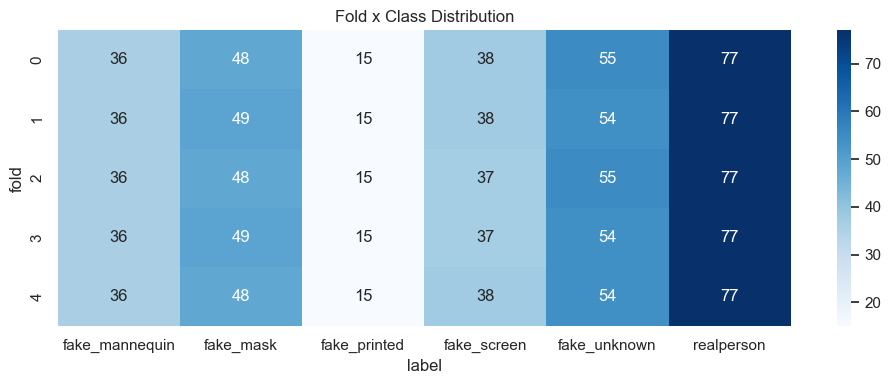

Fold counts:
fold
0    269
1    269
2    268
3    268
4    268


In [8]:
fold_class = pd.crosstab(split_df["fold"], split_df["label"])
display(fold_class)

plt.figure(figsize=(10, 4))
sns.heatmap(fold_class, annot=True, fmt="d", cmap="Blues")
plt.title("Fold x Class Distribution")
plt.ylabel("fold")
plt.xlabel("label")
plt.tight_layout()
plt.show()

fold_counts = split_df["fold"].value_counts().sort_index()
print("Fold counts:")
print(fold_counts.to_string())